In [ ]:
import requests
import pandas as pd
import sqlite3

def extract():
    response = requests.get("https://jsonplaceholder.typicode.com/users")
    if response.status_code == 200:
        return response.json()
    else:
        return None

def transform(data):
    df = pd.DataFrame(data)
    df = df[["id", "name", "username", "email", "phone", "website"]]
    return df

def load(df):
    conn = sqlite3.connect("user.db")
    df.to_sql("user", conn, if_exists="replace", index=False)
    print("saved to database!")

def run_pipeline():
    data = extract()
    df = transform(data)
    load(df)

def query(sql):
    conn = sqlite3.connect("user.db")
    return pd.read_sql(sql, conn)

# run the pipeline
run_pipeline()

# now query!
query("SELECT * FROM user")

saved to database!


,id,name,username,email,phone,website
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info
5,6,Mrs. Dennis Schulist,Leopoldo_Corkery,Karley_Dach@jasper.info,1-477-935-8478 x6430,ola.org
6,7,Kurtis Weissnat,Elwyn.Skiles,Telly.Hoeger@billy.biz,210.067.6132,elvis.io
7,8,Nicholas Runolfsdottir V,Maxime_Nienow,Sherwood@rosamond.me,586.493.6943 x140,jacynthe.com
8,9,Glenna Reichert,Delphine,Chaim_McDermott@dana.io,(775)976-6794 x41206,conrad.com
9,10,Clementina DuBuque,Moriah.Stanton,Rey.Padberg@karina.biz,024-648-3804,ambrose.net


Item 2


In [ ]:
import pandas as pd
import logging
import requests
import sqlite3

logging.basicConfig(level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True)

def extract():
  try:
    response=requests.get("https://jsonplaceholder.typicode.com/users")
    if response.status_code==200:
      logging.info("successful")
      return response.json()
    else :
      logging.warning(f"failed {response.status_code}")
  except Exception as e :
    logging.error(f"error{e}")
    print("FULL ERROR:", e)
    return None
def transform(data):
  try:
    df=pd.DataFrame(data)
    df=df[["id","name","username","email","website"]]
    logging.info(f"transform successful{len(df)}")
    return df
  except Exception as e:
    logging.error(f"error{e}")
    print("FULL ERROR:", e)
    return None
def load(df):
    try:
        conn = sqlite3.connect("user.db")
        df.to_sql("user", conn, if_exists="replace", index=False)
        logging.info("Load successful!")
    except Exception as e:
        logging.error(f"Load failed: {e}")

def run_pipeline():
    print("starting...")
    data = extract()
    print("data:", type(data))
    df = transform(data)
    print("df:", type(df))
    load(df)
    print("done!")
run_pipeline()
def query(sql):
    conn = sqlite3.connect("user.db")
    return pd.read_sql(sql, conn)
query("select * from user")




2026-03-25 16:22:41,661 - INFO - successful
2026-03-25 16:22:41,666 - INFO - transform successful10
2026-03-25 16:22:41,696 - INFO - Load successful!


starting...
data: <class 'list'>
df: <class 'pandas.core.frame.DataFrame'>
done!


,id,name,username,email,website
0,1,Leanne Graham,Bret,Sincere@april.biz,hildegard.org
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,anastasia.net
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,ramiro.info
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,kale.biz
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,demarco.info
5,6,Mrs. Dennis Schulist,Leopoldo_Corkery,Karley_Dach@jasper.info,ola.org
6,7,Kurtis Weissnat,Elwyn.Skiles,Telly.Hoeger@billy.biz,elvis.io
7,8,Nicholas Runolfsdottir V,Maxime_Nienow,Sherwood@rosamond.me,jacynthe.com
8,9,Glenna Reichert,Delphine,Chaim_McDermott@dana.io,conrad.com
9,10,Clementina DuBuque,Moriah.Stanton,Rey.Padberg@karina.biz,ambrose.net


New

In [ ]:
import pandas as pd
import sqlite3
import requests
import logging

logging.basicConfig(level=logging.INFO)
def extract():
  try:
    response=requests.get("https://jsonplaceholder.typicode.com/posts")
    if response.status_code==200:
     logging.info("successful")
     return response.json()

    else:
      logging.warning(f"error{response.status_code}")
  except Exception as e :
    logging.error(f"error{e}")
    return None
def transform(data):
  try:
    df=pd.DataFrame(data)
    df=df[["userId", "id", "title", "body"]]
    logging.info(f"transform successful {len(df)}")
    return df
  except Exception as e:
    logging.error(f"error{e}")
    return None
def load(df):
  try :
    conn=sqlite3.connect("user.db")
    df.to_sql("user",conn,if_exists="replace",index=False)
    logging.info("successful")
  except Exception as e:
    logging.error(f"error{e}")

def run_pipeline():
  data=extract()
  df=transform(data)
  load(df)
run_pipeline()
def query(sql):
    conn = sqlite3.connect("user.db")
    return pd.read_sql(sql, conn)
query("select * from user")




2026-03-25 16:22:41,797 - INFO - successful
2026-03-25 16:22:41,802 - INFO - transform successful 100
2026-03-25 16:22:41,832 - INFO - successful


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
...,...,...,...,...
95,10,96,quaerat velit veniam amet cupiditate aut numqu...,in non odio excepturi sint eum\nlabore volupta...
96,10,97,quas fugiat ut perspiciatis vero provident,eum non blanditiis soluta porro quibusdam volu...
97,10,98,laboriosam dolor voluptates,doloremque ex facilis sit sint culpa\nsoluta a...
98,10,99,temporibus sit alias delectus eligendi possimu...,quo deleniti praesentium dicta non quod\naut e...


In [ ]:
data=extract()

2026-03-25 16:22:42,998 - INFO - successful


Project


In [ ]:
import requests
import sqlite3
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO)
def extract_users():
  try:
    response=requests.get("https://jsonplaceholder.typicode.com/users")
    if response.status_code==200:
      logging.info("success")
      return response.json()
    else:
      logging.warning(f"problen{response.status_code}")
  except Exception as e:
    logging.error(f"error{e}")

def extract_posts():
  try:
    response=requests.get("https://jsonplaceholder.typicode.com/posts")
    if response.status_code==200:
      logging.info("success")
      return response.json()
    else:
      logging.warning(f"problen{response.status_code}")
  except Exception as e:
    logging.error(f"error{e}")

def extract_comments():
  try:
    response=requests.get("https://jsonplaceholder.typicode.com/comments")
    if response.status_code==200:
      logging.info("success")
      return response.json()
    else:
      logging.warning(f"problen{response.status_code}")
  except Exception as e:
    logging.error(f"error{e}")

def transform_users(data):
  try:
   df=pd.DataFrame(data)
   df=df[["id","name","username","phone"]]
   logging.info(f"transform successful {len(df)}")
   return df
  except Exception as e:
    logging.error(f"error{e}")
    return None

def transform_posts(data):
  try:
   df=pd.DataFrame(data)
   df=df[["id","title","body","userId"]]
   logging.info(f"transform successful {len(df)}")
   return df
  except Exception as e:
    logging.error(f"error{e}")
    return None

def transform_comments(data):
   try:
    df=pd.DataFrame(data)
    df=df[["id","name","postId","body"]]
    logging.info(f"transform successful {len(df)}")
    return df
   except Exception as e:
    logging.error(f"error{e}")
    return None


def load(df, table_name):
  try:
    conn = sqlite3.connect("shopmart.db")
    df.to_sql(table_name, conn, if_exists="replace", index=False)
    logging.info(f"{table_name} loaded!")
  except Exception as e:
    logging.error(f"error: {e}")

def run_pipeline():
  users = extract_users()
  df=transform_users(users)
  load(df,"users")
  posts = extract_posts()
  df=transform_posts(posts)
  load(df,"posts")
  comments = extract_comments()
  df=transform_comments(comments)
  load(df,"comments")

run_pipeline()

def query(sql):
    conn = sqlite3.connect("shopmart.db")
    return pd.read_sql(sql, conn)

a=print(query("SELECT * FROM users"))


   id                      name          username                  phone
0   1             Leanne Graham              Bret  1-770-736-8031 x56442
1   2              Ervin Howell         Antonette    010-692-6593 x09125
2   3          Clementine Bauch          Samantha         1-463-123-4447
3   4          Patricia Lebsack          Karianne      493-170-9623 x156
4   5          Chelsey Dietrich            Kamren          (254)954-1289
5   6      Mrs. Dennis Schulist  Leopoldo_Corkery   1-477-935-8478 x6430
6   7           Kurtis Weissnat      Elwyn.Skiles           210.067.6132
7   8  Nicholas Runolfsdottir V     Maxime_Nienow      586.493.6943 x140
8   9           Glenna Reichert          Delphine   (775)976-6794 x41206
9  10        Clementina DuBuque    Moriah.Stanton           024-648-3804


In [ ]:
print(query("SELECT * FROM posts"))


     id                                              title  \
0     1  sunt aut facere repellat provident occaecati e...   
1     2                                       qui est esse   
2     3  ea molestias quasi exercitationem repellat qui...   
3     4                               eum et est occaecati   
4     5                                 nesciunt quas odio   
..  ...                                                ...   
95   96  quaerat velit veniam amet cupiditate aut numqu...   
96   97         quas fugiat ut perspiciatis vero provident   
97   98                        laboriosam dolor voluptates   
98   99  temporibus sit alias delectus eligendi possimu...   
99  100              at nam consequatur ea labore ea harum   

                                                 body  userId  
0   quia et suscipit\nsuscipit recusandae consequu...       1  
1   est rerum tempore vitae\nsequi sint nihil repr...       1  
2   et iusto sed quo iure\nvoluptatem occaecati om...       1  

In [ ]:
print(query("SELECT * FROM comments"))

      id                                               name  postId  \
0      1                       id labore ex et quam laborum       1   
1      2          quo vero reiciendis velit similique earum       1   
2      3                      odio adipisci rerum aut animi       1   
3      4                                     alias odio sit       1   
4      5              vero eaque aliquid doloribus et culpa       1   
..   ...                                                ...     ...   
495  496  et occaecati asperiores quas voluptas ipsam no...     100   
496  497             doloribus dolores ut dolores occaecati     100   
497  498                           dolores minus aut libero     100   
498  499  excepturi sunt cum a et rerum quo voluptatibus...     100   
499  500                                 ex eaque eum natus     100   

                                                  body  
0    laudantium enim quasi est quidem magnam volupt...  
1    est natus enim nihil est dol

In [ ]:
query("""with a as(select p.id as name, count(c.postId) as total from posts p left join comments c on p.id=c.postId group by p.id)
select total, max(total) , avg(total) from a group by name""")

,total,max(total),avg(total)
0,5,5,5.0
1,5,5,5.0
2,5,5,5.0
3,5,5,5.0
4,5,5,5.0
...,...,...,...
95,5,5,5.0
96,5,5,5.0
97,5,5,5.0
98,5,5,5.0


In [ ]:
df5=query(""" Select u.name,count(distinct p.id) as total_posts, count(c.id) as total_comments from users u left join posts p on u.id=p.userId
 left join comments c on p.id=c.postId group by u.name order by  count(c.id) desc""")

Text(0, 0.5, 'count')

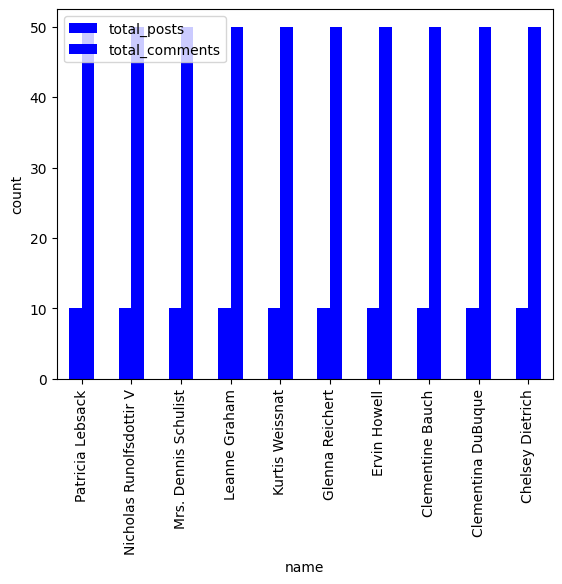

In [ ]:
zx=df5.plot(kind="bar",color="blue",x="name", y=["total_posts", "total_comments"])
zx.set_xlabel("name")
zx.set_ylabel("count")


In [ ]:
df1=query("""select u.name as name ,count(p.id)as total from users u left join posts p on p.userId=u.id group by u.name order by count(p.id) desc""")

In [ ]:
query("""with a as(select u.name as name ,count(p.id)as total from users u left join posts p on p.userId=u.id group by u.name order by count(p.id) desc)
select dense_rank() over(order by total desc ) from a""")

,dense_rank() over(order by total desc )
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [ ]:
print(query("SELECT * FROM posts"))


     id                                              title  \
0     1  sunt aut facere repellat provident occaecati e...   
1     2                                       qui est esse   
2     3  ea molestias quasi exercitationem repellat qui...   
3     4                               eum et est occaecati   
4     5                                 nesciunt quas odio   
..  ...                                                ...   
95   96  quaerat velit veniam amet cupiditate aut numqu...   
96   97         quas fugiat ut perspiciatis vero provident   
97   98                        laboriosam dolor voluptates   
98   99  temporibus sit alias delectus eligendi possimu...   
99  100              at nam consequatur ea labore ea harum   

                                                 body  userId  
0   quia et suscipit\nsuscipit recusandae consequu...       1  
1   est rerum tempore vitae\nsequi sint nihil repr...       1  
2   et iusto sed quo iure\nvoluptatem occaecati om...       1  

In [ ]:
query(""" select userId from posts where userId in (select userId from posts group by userId having count(id)>10 )""")

,userId


In [ ]:
print(query("SELECT * FROM comments"))

      id                                               name  postId  \
0      1                       id labore ex et quam laborum       1   
1      2          quo vero reiciendis velit similique earum       1   
2      3                      odio adipisci rerum aut animi       1   
3      4                                     alias odio sit       1   
4      5              vero eaque aliquid doloribus et culpa       1   
..   ...                                                ...     ...   
495  496  et occaecati asperiores quas voluptas ipsam no...     100   
496  497             doloribus dolores ut dolores occaecati     100   
497  498                           dolores minus aut libero     100   
498  499  excepturi sunt cum a et rerum quo voluptatibus...     100   
499  500                                 ex eaque eum natus     100   

                                                  body  
0    laudantium enim quasi est quidem magnam volupt...  
1    est natus enim nihil est dol

In [ ]:
query("""with a as(select p.title as name, c.id as total from posts p left join comments c on p.id=c.postId )
select count( total) from a group by name""")

,count( total)
0,5
1,5
2,5
3,5
4,5
...,...
95,5
96,5
97,5
98,5


In [ ]:
query("""select name,row_number() over(partition by postId) from comments""")

,name,row_number() over(partition by postId)
0,id labore ex et quam laborum,1
1,quo vero reiciendis velit similique earum,2
2,odio adipisci rerum aut animi,3
3,alias odio sit,4
4,vero eaque aliquid doloribus et culpa,5
...,...,...
495,et occaecati asperiores quas voluptas ipsam no...,1
496,doloribus dolores ut dolores occaecati,2
497,dolores minus aut libero,3
498,excepturi sunt cum a et rerum quo voluptatibus...,4


In [ ]:
query("""select sum(id) over(order by userId) from posts""")

,sum(id) over(order by userId)
0,55
1,55
2,55
3,55
4,55
...,...
95,5050
96,5050
97,5050
98,5050


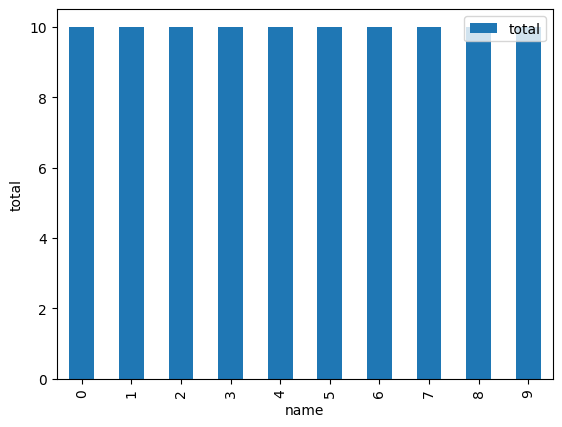

In [ ]:
import matplotlib.pyplot as plt

ax = df1.plot(kind='bar')
ax.set_xlabel("name")
ax.set_ylabel("total")
plt.show()

In [ ]:
df2=query("""select p.title as title, count(c.id) as total from posts p left join comments c on p.id=c.postId group by p.title order by count(c.id) desc""")

Text(0, 0.5, 'total')

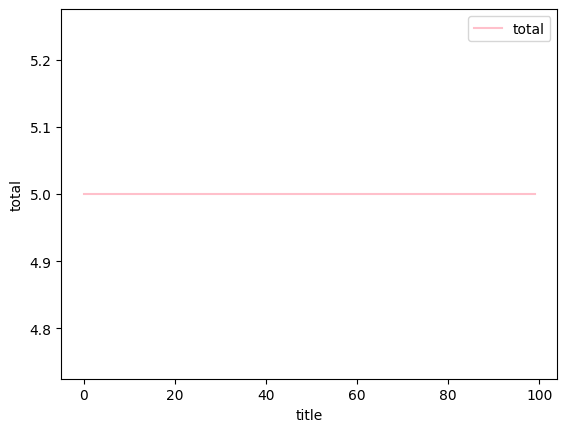

In [ ]:
yx=df2.plot(kind="line",color="pink")
yx.set_xlabel("title")
yx.set_ylabel("total")

In [ ]:
df3=query("""with a as (select count(id) as total,userId from posts group by userId) select avg(total) from a""")

In [ ]:
df4=query("""WITH user_post_counts AS (
    SELECT u.name, COUNT(p.id) AS post_count
    FROM users u
    LEFT JOIN posts p ON p.userId = u.id
    GROUP BY u.name
)
SELECT
    COUNT(CASE WHEN post_count > 10 THEN 1 END)  * 100 / count(post_count) AS percentage_users_with_more_than_10_posts
FROM user_post_counts;""")

In [ ]:
from pydantic import BaseModel

class User(BaseModel):
  id:int
  name:str
  username:str
  phone:str
def validate_users(data):
    valid_rows = []

    for row in data:
        try:
            user = User(**row)        # check each row
            valid_rows.append(user.dict())  # if valid, keep it
        except Exception as e:
            logging.warning(f"Invalid row skipped: {e}")  # if invalid, skip it

        print(f"Total valid rows: {len(valid_rows)}")  # ← add this
    return valid_rows



In [ ]:
def run_pipeline():
    # extract
    users_data = extract_users()

    # validate ← new step!
    clean_data = validate_users(users_data)

    # transform
    df = transform_users(clean_data)

    # load
    load(df, "users")

In [ ]:
run_pipeline()

Total valid rows: 1
Total valid rows: 2
Total valid rows: 3
Total valid rows: 4
Total valid rows: 5
Total valid rows: 6
Total valid rows: 7
Total valid rows: 8
Total valid rows: 9
Total valid rows: 10


/tmp/ipykernel_2159/1205982826.py:14: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  valid_rows.append(user.dict())  # if valid, keep it
